In [1]:
# %% Cell 1: imports
import sys, torch, numpy as np
sys.path.append('..'); sys.path.append('../..')

from common.seed import set_seed
from common.io_utils import save_results, load_results
from backbones.backbones import get_resnet50, get_vit, get_clip, extract_all_features
from img_prep.make_subset import load_stl10
from img_prep.transforms import (to_common_224, resnet_normalize, vit_normalize,
                                  clip_normalize, translate_transform)
from evaluations.evaluate_bias import evaluate_head_with_preds, prediction_consistency, clip_zero_shot_eval, clip_zero_shot_batched
import open_clip, torch.nn as nn
import matplotlib.pyplot as plt
from pathlib import Path

set_seed(6304)
device = "cuda" if torch.cuda.is_available() else "cpu"
Path("../../report/figures").mkdir(parents=True, exist_ok=True)

In [2]:
# %% Cell 2: same subset, same clean reference
subset_ids = load_results("../results/subset_ids.json")
test_idx = subset_ids["test_subset_indices"]
clean_preds = load_results("../results/clean_predictions.json")["predictions"]
clean_baseline = load_results("../results/clean_baseline.json")["models"]

test_ds = load_stl10(split='test')
class_names = ['airplane','bird','car','cat','deer','dog','horse','monkey','ship','truck']

In [3]:
# %% Cell 3: backbones + saved heads
resnet, _ = get_resnet50(); vit, _ = get_vit(); clip_model, _ = get_clip()
tokenizer = open_clip.get_tokenizer('ViT-B-32')

def load_head(name, in_dim):
    head = nn.Linear(in_dim, 10).to(device)
    head.load_state_dict(torch.load(f"../../datasets/cache/{name}_head.pth", map_location=device))
    head.eval(); return head

heads = {"resnet50": load_head("resnet50", 2048),
         "vit_b16": load_head("vit_b16", 768),
         "clip_head": load_head("clip_head", 512)}

backbones_info = [("resnet50", resnet, resnet_normalize, "resnet_or_vit"),
                  ("vit_b16", vit, vit_normalize, "resnet_or_vit"),
                  ("clip", clip_model, clip_normalize, "clip")]

In [4]:
# %% Cell 4: sweep displacements x directions
shifts = [0, 8, 16, 32]
directions = ['up', 'down', 'left', 'right']
model_names = ["resnet50", "vit_b16", "clip_head", "clip_zeroshot"]

results = {"step": "translation", "seed": 6304,
           "shifts": shifts, "directions": directions, "curves": {m: {} for m in model_names}}

for shift in shifts:
    per_dir = {m: {"acc": [], "cons": []} for m in model_names}

    for direction in directions:
        interv = lambda x, s=shift, d=direction: translate_transform(x, s, d)

        for name, model, norm_fn, mtype in backbones_info:
            feats, labels = extract_all_features(model, test_ds, test_idx, norm_fn,
                                                  model_type=mtype, intervention_fn=interv,
                                                  device=device)
            if name == "clip":
                m_, p_ = evaluate_head_with_preds(heads["clip_head"], feats, labels)
                per_dir["clip_head"]["acc"].append(m_["top1_acc"])
                per_dir["clip_head"]["cons"].append(
                    prediction_consistency(np.array(clean_preds["clip_head"]), p_))

                imgs = torch.stack([clip_normalize(interv(to_common_224(test_ds[i][0])))
                                     for i in test_idx])
                zm, zp = clip_zero_shot_batched(clip_model, tokenizer, imgs, labels,
                                                 class_names, device=device)
                per_dir["clip_zeroshot"]["acc"].append(zm["top1_acc"])
                per_dir["clip_zeroshot"]["cons"].append(
                    prediction_consistency(np.array(clean_preds["clip_zeroshot"]), zp))
                del imgs
                torch.cuda.empty_cache()
            else:
                m_, p_ = evaluate_head_with_preds(heads[name], feats, labels)
                per_dir[name]["acc"].append(m_["top1_acc"])
                per_dir[name]["cons"].append(
                    prediction_consistency(np.array(clean_preds[name]), p_))

            del feats
            torch.cuda.empty_cache()

    for m in model_names:
        results["curves"][m][str(shift)] = {
            "acc_mean": float(np.mean(per_dir[m]["acc"])),
            "acc_std": float(np.std(per_dir[m]["acc"])),
            "consistency_mean": float(np.mean(per_dir[m]["cons"])),
            "consistency_std": float(np.std(per_dir[m]["cons"])),
            "per_direction_acc": dict(zip(directions, per_dir[m]["acc"])),
        }
    print(f"shift {shift:>2}px: " + "  ".join(
        f"{m} acc={results['curves'][m][str(shift)]['acc_mean']:.3f}" for m in model_names))

shift  0px: resnet50 acc=0.952  vit_b16 acc=0.964  clip_head acc=0.966  clip_zeroshot acc=0.964
shift  8px: resnet50 acc=0.950  vit_b16 acc=0.960  clip_head acc=0.965  clip_zeroshot acc=0.960
shift 16px: resnet50 acc=0.948  vit_b16 acc=0.961  clip_head acc=0.960  clip_zeroshot acc=0.959
shift 32px: resnet50 acc=0.939  vit_b16 acc=0.961  clip_head acc=0.950  clip_zeroshot acc=0.943


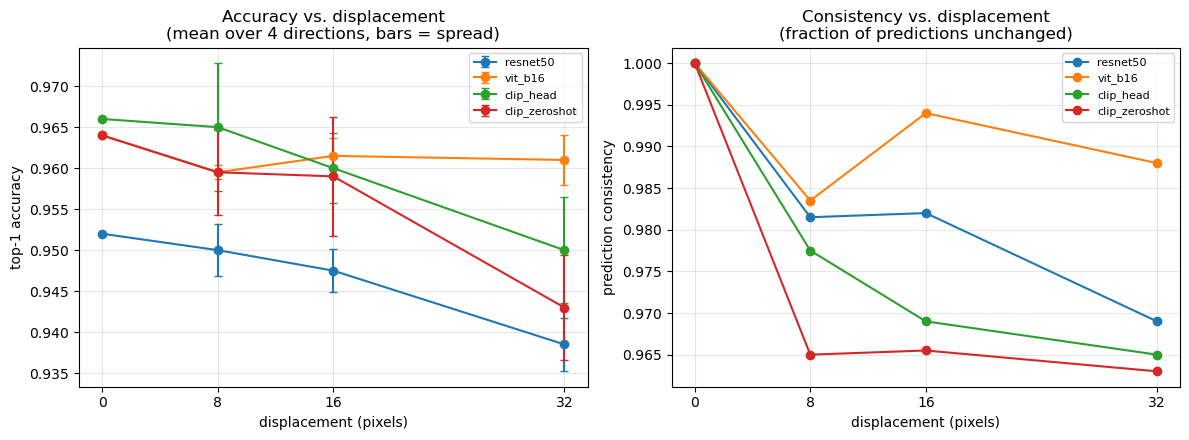

In [5]:
# %% Cell 5: the required curve figure
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for m in model_names:
    accs = [results["curves"][m][str(s)]["acc_mean"] for s in shifts]
    stds = [results["curves"][m][str(s)]["acc_std"] for s in shifts]
    cons = [results["curves"][m][str(s)]["consistency_mean"] for s in shifts]
    axes[0].errorbar(shifts, accs, yerr=stds, marker='o', capsize=3, label=m)
    axes[1].plot(shifts, cons, marker='o', label=m)

axes[0].set_xlabel("displacement (pixels)"); axes[0].set_ylabel("top-1 accuracy")
axes[0].set_title("Accuracy vs. displacement\n(mean over 4 directions, bars = spread)")
axes[1].set_xlabel("displacement (pixels)"); axes[1].set_ylabel("prediction consistency")
axes[1].set_title("Consistency vs. displacement\n(fraction of predictions unchanged)")
for ax in axes:
    ax.set_xticks(shifts); ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig("../../report/figures/translation_curves.png", dpi=200, bbox_inches='tight')
plt.show()

In [6]:
# %% Cell 6: save
save_results(results, "../results/translation.json")